<table style="background-color: #f0f0f0; padding: 10px; width: auto;">  
<tr>                                                                      
<td style="background-color: #ffffff; vertical-align: middle;">         
<img src="https://th.bing.com/th/id/OIP.zZshkvEYWRVv1orlaBMmjwHaHa?w=155&h=180&c=7&r=0&o=5&pid=1.7" alt="Logo" style="width: 150px;"/>
</td>
<td style="text-align: left; vertical-align: middle; padding-left: 10px;">
<h2 style="color: #2c3e50; margin: 5;">UNIVERSIDAD NACIONAL AGRARIA LA MOLINA</h2>                                                                
<h3 style="color: #2c3e50; margin: 5;">FACULTAD DE ECONOMÍA Y PLANIFICACIÓN</h3>  
<h5 style="color: #2c3e50; margin: 5;">DEPARTAMENTO DE ESTADÍSTICA E INFORMÁTICA</h5>
</td>
</tr>                                                                      
</table>

**Curso:** Lenguaje de Programación II  

**Docente:** Chalan Llajaruna, Denise

**Turno:** D

|**Integrantes**| Código |  
| :--- | :--- |  
| 1. Aguilar Farfán, Juan Fernando | 20241372 |  
| 2. Delgado Conzuero, Nathaly |20201406 |
| 3. Guevara Alvarado, Samuel Christian | 20241384 |  
| 4. Pacheco Pampas, Merly Vanessa | 20241392 |
| 5. Santillan Santa Cruz, Alex | 20241402 |

# **<center><u><b><p style="color:Darkred;">Caso: Análisis de ofertas de empleo a partir de datos extraídos mediante una API</p></b></u></center>**


## **1. Introducción**

Buscar empleo por internet se ha vuelto parte de la vida diaria de muchas personas. Cada día se publican miles de ofertas laborales con información sobre puestos, salarios, requisitos y modalidades de trabajo. Ante la gran cantidad de datos disponibles, surge la necesidad de contar con herramientas que permitan recopilar y analizar esta información de forma automática. Por ello, este proyecto desarrolla un sistema que extrae ofertas de empleo mediante una API y las procesa para obtener información útil sobre las características del mercado laboral.

## **2. Objetivos:**

### **2.1. Objetivo general**
Desarrollar una herramienta que permita recopilar y analizar información de ofertas de empleo publicadas en internet, utilizando una API para conocer mejor las características de las oportunidades laborales disponibles.
### **2.1. Objetivo general**

* Obtener automáticamente ofertas de empleo desde una API y almacenar la información recopilada para su posterior análisis.
* Organizar y depurar los datos obtenidos, eliminando información innecesaria y dejando un conjunto de datos más claro y fácil de trabajar.
* Identificar información importante dentro de las descripciones de las ofertas, como las tecnologías solicitadas, la modalidad de trabajo y la experiencia requerida.
* Explorar y representar los datos obtenidos mediante análisis y gráficos que permitan comprender mejor las características de las ofertas de empleo recopiladas.



## **3. Desarrollo del sistema**

### **3.1. Obtención de las ofertas de empleo**
En esta etapa se realiza la conexión con la API para recopilar las ofertas de empleo disponibles. La información obtenida se almacena en un archivo JSON, lo que permite conservar los datos originales y utilizarlos posteriormente en las etapas de limpieza y análisis.

In [2]:
### AQUI VA EL CODIGO DE EXTRACCION USANDO LA API
import requests
import json
import time
import os


class ScraperHiringCafe:
    """
    Clase para extraer ofertas de trabajo de Himalayas.app vía API.
    """

    def __init__(self):
        self.base_url = "https://himalayas.app/jobs/api"
        self.ofertas = []

    def obtener_ofertas(self, limite=20, offset=0):
        """
        Obtiene una página de ofertas de trabajo desde la API.
        """
        params = {
            "limit": limite,
            "offset": offset
        }

        try:
            response = requests.get(self.base_url, params=params, timeout=10)
            response.raise_for_status()
            return response.json()

        except requests.exceptions.RequestException as e:
            print(f"Error al obtener datos: {e}")
            return None

    def guardar_json(self, datos, nombre="datos/crudos/ofertas_hiringcafe.json"):
        """
        Guarda los datos obtenidos en un archivo JSON.
        """
        os.makedirs(os.path.dirname(nombre), exist_ok=True)

        with open(nombre, "w", encoding="utf-8") as archivo:
            json.dump(datos, archivo, ensure_ascii=False, indent=4)

        print(f"Datos guardados en: {nombre}")

    def ejecutar_scraping(self, max_ofertas=100):
        """
        Ejecuta la extracción de ofertas utilizando paginación.
        """
        todas_las_ofertas = []
        offset = 0
        limite = 20  # Máximo permitido por solicitud

        while len(todas_las_ofertas) < max_ofertas:

            print(f"Obteniendo ofertas desde offset {offset}...")

            data = self.obtener_ofertas(limite=limite, offset=offset)

            if not data or not data.get("jobs"):
                print("No se encontraron más ofertas.")
                break

            ofertas_pagina = data["jobs"]
            todas_las_ofertas.extend(ofertas_pagina)

            print(f"→ {len(ofertas_pagina)} ofertas obtenidas")

            if offset + limite >= data.get("totalCount", 0):
                break

            offset += limite

            # Espera de 1 segundo entre solicitudes
            time.sleep(1)

        self.ofertas = todas_las_ofertas

        print(f"\nTotal de ofertas obtenidas: {len(self.ofertas)}")

        return self.ofertas


if __name__ == "__main__":

    scraper = ScraperHiringCafe()

    ofertas = scraper.ejecutar_scraping(max_ofertas=100)

    scraper.guardar_json(ofertas)

Obteniendo ofertas desde offset 0...
→ 20 ofertas obtenidas
Obteniendo ofertas desde offset 20...
→ 20 ofertas obtenidas
Obteniendo ofertas desde offset 40...
→ 20 ofertas obtenidas
Obteniendo ofertas desde offset 60...
→ 20 ofertas obtenidas
Obteniendo ofertas desde offset 80...
→ 20 ofertas obtenidas

Total de ofertas obtenidas: 100
Datos guardados en: datos/crudos/ofertas_hiringcafe.json


Se lograron recopilar 100 ofertas de empleo mediante el consumo de la API. La información fue obtenida de forma gradual, en bloques de 20 ofertas por solicitud, hasta completar el conjunto de datos requerido. Finalmente, los registros extraídos se guardaron en un archivo JSON para ser utilizados en las etapas posteriores del proyecto.

### **3.2. Preparación y limpieza de los datos**
Una vez obtenidas las ofertas, los datos son organizados y depurados para facilitar su análisis. En esta etapa se eliminan registros duplicados, se manejan valores faltantes y se crean nuevas variables que permiten describir mejor las características de las ofertas de empleo.

In [3]:
import pandas as pd
import json
import os

class ProcesadorDatos:
    """
    Clase para procesar y limpiar los datos de ofertas de trabajo
    """

    def __init__(self, archivo_json="datos/crudos/ofertas_hiringcafe.json"):
        """
        Inicializa el procesador cargando los datos del JSON
        """
        self.ruta_json = archivo_json
        self.df = None
        self._cargar_datos()

    def _cargar_datos(self):
        """
        Carga el archivo JSON y lo convierte a DataFrame de pandas
        Método interno (empieza con _)
        """
        try:
            with open(self.ruta_json, 'r', encoding='utf-8') as f:
                data = json.load(f)

            self.df = pd.DataFrame(data)
            print(f"Datos cargados correctamente: {len(self.df)} ofertas")
            print(f"   Columnas disponibles: {list(self.df.columns)}")
            return self.df
        except FileNotFoundError:
            print(f"ERROR: No se encontró el archivo: {self.ruta_json}")
            print("   Asegúrate de haber ejecutado primero el scraper")
            self.df = pd.DataFrame()
            return self.df

    def limpiar_datos(self):
        """
        Realiza la limpieza completa del dataset
        """
        if self.df.empty:
            print("No hay datos para limpiar")
            return self.df

        print("\nINICIANDO LIMPIEZA DE DATOS")
        print("=" * 40)

        # 1. Eliminar duplicados
        registros_antes = len(self.df)
        self.df = self.df.drop_duplicates(subset=['title', 'companyName'])
        print(f"   → Duplicados eliminados: {registros_antes - len(self.df)}")

        # 2. Manejar valores nulos
        self.df['description'] = self.df['description'].fillna('')
        self.df['minSalary'] = self.df['minSalary'].fillna(0)
        self.df['maxSalary'] = self.df['maxSalary'].fillna(0)
        self.df['currency'] = self.df['currency'].fillna('No especificado')
        self.df['employmentType'] = self.df['employmentType'].fillna('No especificado')

        # 3. Limpiar descripciones (eliminar HTML)
        self.df['description'] = self.df['description'].str.replace(r'<[^<>]*>', '', regex=True)
        self.df['description'] = self.df['description'].str.replace(r'\s+', ' ', regex=True)
        self.df['description'] = self.df['description'].str.strip()

        # 4. Convertir fechas
        self.df['pubDate'] = pd.to_datetime(self.df['pubDate'], unit='ms')

        # 5. Extraer ubicaciones
        if 'locationRestrictions' in self.df.columns:
            self.df['ubicacion'] = self.df['locationRestrictions'].apply(
                lambda x: ', '.join(x) if isinstance(x, list) and x else 'Global'
            )
        else:
            self.df['ubicacion'] = 'Global'

        # 6. Extraer seniority
        if 'seniority' in self.df.columns:
            self.df['seniority'] = self.df['seniority'].apply(
                lambda x: ', '.join(x) if isinstance(x, list) and x else 'No especificado'
            )
        else:
            self.df['seniority'] = 'No especificado'

        # 7. Crear rango salarial formateado
        self.df['rango_salarial'] = self.df.apply(
            lambda row: f"{row['minSalary']} - {row['maxSalary']} {row['currency']}"
            if row['minSalary'] > 0 and row['maxSalary'] > 0 else 'No especificado',
            axis=1
        )

        # 8. Crear salario promedio
        self.df['salario_promedio'] = self.df.apply(
            lambda row: (row['minSalary'] + row['maxSalary']) / 2
            if row['minSalary'] > 0 and row['maxSalary'] > 0 else None,
            axis=1
        )

        # 9. Tipo de empleo simplificado
        self.df['tipo_empleo_simple'] = self.df['employmentType'].apply(
            lambda x: 'Full Time' if 'full' in x.lower() else
                     'Part Time' if 'part' in x.lower() else
                     'Contract' if 'contract' in x.lower() else
                     'Freelance' if 'freelance' in x.lower() else 'Otro'
        )

        print(f"   → Datos limpios: {len(self.df)} registros")
        print("LIMPIEZA COMPLETADA")
        return self.df

    def guardar_csv(self, nombre="datos/procesados/ofertas_limpias.csv"):
        """
        Guarda el DataFrame limpio en un archivo CSV
        """
        if self.df.empty:
            print("No hay datos para guardar")
            return

        # Crear la carpeta si no existe
        os.makedirs(os.path.dirname(nombre), exist_ok=True)

        self.df.to_csv(nombre, index=False, encoding='utf-8-sig')
        print(f"Datos guardados en: {nombre}")
        print(f" Total de registros: {len(self.df)}")

    def mostrar_resumen(self):
        """
        Muestra un resumen estadístico del dataset
        """
        if self.df.empty:
            print("No hay datos para mostrar")
            return

        print("\n" + "=" * 50)
        print("RESUMEN DEL DATASET")
        print("=" * 50)

        print(f"📌 Total de ofertas: {len(self.df)}")
        print(f"📌 Columnas: {len(self.df.columns)}")

        print("\nTipos de empleo:")
        print(self.df['tipo_empleo_simple'].value_counts())

        print("\nTop 5 empresas con más ofertas:")
        print(self.df['companyName'].value_counts().head())

        salarios_validos = self.df[self.df['salario_promedio'].notna()]
        if not salarios_validos.empty:
            print(f"\n Salarios promedio:")
            print(f"   Mínimo: ${salarios_validos['salario_promedio'].min():,.0f}")
            print(f"   Promedio: ${salarios_validos['salario_promedio'].mean():,.0f}")
            print(f"   Máximo: ${salarios_validos['salario_promedio'].max():,.0f}")

    def ejecutar_procesamiento(self):
        """
        Método principal que ejecuta todo el flujo de procesamiento
        """
        print("INICIANDO PROCESAMIENTO DE DATOS")
        print("=" * 50)

        self.limpiar_datos()
        self.guardar_csv()
        self.mostrar_resumen()

        print("\nPROCESAMIENTO COMPLETADO EXITOSAMENTE")
        return self.df


if __name__ == "__main__":
    procesador = ProcesadorDatos("datos/crudos/ofertas_hiringcafe.json")
    df_limpio = procesador.ejecutar_procesamiento()

Datos cargados correctamente: 100 ofertas
   Columnas disponibles: ['title', 'excerpt', 'companyName', 'companySlug', 'companyLogo', 'employmentType', 'minSalary', 'maxSalary', 'salaryPeriod', 'seniority', 'currency', 'locationRestrictions', 'timezoneRestrictions', 'categories', 'parentCategories', 'description', 'pubDate', 'expiryDate', 'applicationLink', 'guid']
INICIANDO PROCESAMIENTO DE DATOS

INICIANDO LIMPIEZA DE DATOS
   → Duplicados eliminados: 0
   → Datos limpios: 100 registros
LIMPIEZA COMPLETADA
Datos guardados en: datos/procesados/ofertas_limpias.csv
 Total de registros: 100

RESUMEN DEL DATASET
📌 Total de ofertas: 100
📌 Columnas: 24

Tipos de empleo:
tipo_empleo_simple
Full Time    78
Contract     15
Part Time     6
Otro          1
Name: count, dtype: int64

Top 5 empresas con más ofertas:
companyName
name           20
Nagarro         8
Hire Hangar     6
Comfrt          4
Welo Global     3
Name: count, dtype: int64

 Salarios promedio:
   Mínimo: $8
   Promedio: $94,208
 

Los datos se cargaron correctamente, obteniéndose un total de 100 ofertas de empleo. Durante la limpieza no se encontraron registros duplicados, por lo que se conservaron todas las ofertas. La mayoría de los puestos corresponden a empleos de tiempo completo (78), seguidos por contratos (15) y empleos de medio tiempo (6). Además, algunas empresas, como Nagarro y Hire Hangar, concentran una mayor cantidad de publicaciones. Finalmente, el conjunto de datos limpio se guardó en un archivo CSV para continuar con el análisis.

### **3.3. Extracción de información relevante**
Con los datos ya organizados, se analizó el contenido de la columna description para obtener información que no se encontraba de forma estructurada en el conjunto de datos original. Mediante el uso de expresiones regulares, se extrajeron variables como las tecnologías requeridas (tecnologias), los salarios mencionados en la descripción (salario_mencionado), la modalidad de trabajo (modalidad), el nivel de experiencia solicitado (nivel_experiencia) y los años de experiencia requeridos (anos_experiencia). La incorporación de estas nuevas variables permitió enriquecer el conjunto de datos y obtener una descripción más detallada de las características presentes en las ofertas de empleo recopiladas.

In [4]:
"""
Clase para extraer información usando expresiones regulares (regex)
"""

import re
import pandas as pd
import os

class ExtractorRegex:
    """
    Clase que se usa para extraer información
    de las descripciones de ofertas de trabajo
    """

    def __init__(self, ruta_csv="datos/procesados/ofertas_limpias.csv"):
        """
        Inicializa el extractor cargando el CSV limpio
        El argumento ruta_csv (str): Ruta al archivo CSV con datos ya limpios
        """
        self.ruta_csv = ruta_csv
        self.df = None
        self._cargar_datos()

    def _cargar_datos(self):
        """
        Carga el CSV que genera procesador.py y lo convierte a DataFrame de pandas
        """
        try:
            self.df = pd.read_csv(self.ruta_csv, encoding='utf-8-sig')
            print(f"Datos cargados: {len(self.df)} ofertas")
            print(f" Columnas disponibles: {list(self.df.columns)}")
            return self.df
        except FileNotFoundError:
            print(f"ERROR: No se encontró el archivo: {self.ruta_csv}")
            print(" Verifica que hayas ejecutado primero el procesador")
            self.df = pd.DataFrame()
            return self.df
     # ========== MÉTODOS DE EXTRACCIÓN CON REGEX ==========
    def extraer_tecnologias(self, texto):
        """
        Extrae tecnologías mencionadas en el texto

        Args:
            texto (str): Texto de la descripción

        Returns:
            list: Lista de tecnologías encontradas (sin duplicados)
        """
        if not isinstance(texto, str) or pd.isna(texto):
            return []

        # Patrón para buscar tecnologías comunes
        patron = r'\b(Python|SQL|Java|JavaScript|React|Node\.js|AWS|Docker|Kubernetes|Git|Linux|TypeScript|Angular|Vue|C#|PHP|Ruby|Go|Rust|Elixir|Swift|Kotlin|Scala|Perl|Shell|Bash|PowerShell|Terraform|Ansible|Jenkins|GitLab|GitHub|Jira|Confluence|Slack|PostgreSQL|MySQL|MongoDB|Redis|Elasticsearch|Kafka|RabbitMQ|Nginx|Apache|Flask|Django|Spring|.NET|Express|Next\.js|GraphQL|REST|API|HTML|CSS|Sass|Tailwind|Bootstrap|Figma|Photoshop|Illustrator|Premiere|After Effects)\b'

        tecnologias = re.findall(patron, texto, re.IGNORECASE)

        # Convertir a conjunto para eliminar duplicados, luego a lista
        return list(set(tecnologias))

    def extraer_salario_texto(self, texto):
        """
        Extrae menciones de salario del texto

        Args:
            texto (str): Texto de la descripción

        Returns:
            str: Rango salarial encontrado o None
        """
        if not isinstance(texto, str) or pd.isna(texto):
            return None

        # Patrón para buscar rangos salariales
        patrones = [
            r'\$?(\d{2,3}(?:,\d{3})?(?:k|K)?)\s*[-–]\s*\$?(\d{2,3}(?:,\d{3})?(?:k|K)?)',
            r'(?:USD|usd)?\s*(\d{2,3}(?:,\d{3})?(?:k|K)?)\s*[-–]\s*(\d{2,3}(?:,\d{3})?(?:k|K)?)',
            r'(\d{2,3}(?:,\d{3})?(?:k|K)?)\s*-\s*(\d{2,3}(?:,\d{3})?(?:k|K)?)'
        ]

        for patron in patrones:
            match = re.search(patron, texto, re.IGNORECASE)
            if match:
                return f"${match.group(1)} - ${match.group(2)}"

        return None

    def extraer_modalidad(self, texto):
        """
        Extrae la modalidad de trabajo del texto

        Args:
            texto (str): Texto de la descripción

        Returns:
            str: Modalidad encontrada o 'No especificado'
        """
        if not isinstance(texto, str) or pd.isna(texto):
            return 'No especificado'

        # Patrón para buscar modalidades
        patron = r'\b(Remote|Hybrid|Onsite|Presencial|Remoto|Híbrido|Hibrido|Home Office|Teletrabajo)\b'

        match = re.search(patron, texto, re.IGNORECASE)
        if match:
            # Convertir a formato consistente
            modalidad = match.group(1).lower()
            if modalidad in ['remote', 'remoto', 'home office', 'teletrabajo']:
                return 'Remoto'
            elif modalidad in ['hybrid', 'híbrido', 'hibrido']:
                return 'Híbrido'
            elif modalidad in ['onsite', 'presencial']:
                return 'Presencial'

        return 'No especificado'

    def extraer_nivel_experiencia(self, texto):
        """
        Extrae el nivel de experiencia requerido

        Args:
            texto (str): Texto de la descripción

        Returns:
            str: Nivel de experiencia o 'No especificado'
        """
        if not isinstance(texto, str) or pd.isna(texto):
            return 'No especificado'

        patron = r'\b(Senior|Junior|Entry Level|Mid-Level|Lead|Principal|Staff|Intern|Trainee|Associate)\b'

        match = re.search(patron, texto, re.IGNORECASE)
        if match:
            return match.group(1).title()

        return 'No especificado'

    def extraer_años_experiencia(self, texto):
        """
        Extrae los años de experiencia requeridos usando regex

        Args:
            texto (str): Texto de la descripción

        Returns:
            str: Años de experiencia o None
        """
        if not isinstance(texto, str) or pd.isna(texto):
            return None

        patron = r'(\d+)\+?\s*(?:-?\s*(\d+))?\s*(?:years|años|yr|yrs)'

        match = re.search(patron, texto, re.IGNORECASE)
        if match:
            if match.group(2):  # Rango: X-Y años
                return f"{match.group(1)}-{match.group(2)} años"
            return f"{match.group(1)}+ años"  # X+ años

        return None

    # ========== MÉTODO PRINCIPAL ==========

    def procesar_dataset(self):
        """
        Aplica todas las extracciones al dataset y agrega nuevas columnas
        """
        if self.df.empty:
            print("No hay datos para procesar")
            return self.df

        print("\nEXTRACCIÓN CON EXPRESIONES REGULARES")
        print("=" * 50)

        # Aplicar cada extracción a la columna 'description'
        print("   Extrayendo tecnologías...")
        self.df['tecnologias'] = self.df['description'].apply(self.extraer_tecnologias)

        print("   Extrayendo salarios mencionados...")
        self.df['salario_mencionado'] = self.df['description'].apply(self.extraer_salario_texto)

        print("   Extrayendo modalidad de trabajo...")
        self.df['modalidad'] = self.df['description'].apply(self.extraer_modalidad)

        print("   Extrayendo nivel de experiencia...")
        self.df['nivel_experiencia'] = self.df['description'].apply(self.extraer_nivel_experiencia)

        print("   Extrayendo años de experiencia...")
        self.df['anos_experiencia'] = self.df['description'].apply(self.extraer_años_experiencia)

        # Contar cuántas ofertas tienen cada extracción
        print("\nRESULTADOS DE EXTRACCIÓN:")
        print(f"   - Ofertas con tecnologías: {self.df['tecnologias'].apply(len).gt(0).sum()}")
        print(f"   - Ofertas con salario mencionado: {self.df['salario_mencionado'].notna().sum()}")
        print(f"   - Ofertas con modalidad: {self.df['modalidad'].ne('No especificado').sum()}")
        print(f"   - Ofertas con nivel experiencia: {self.df['nivel_experiencia'].ne('No especificado').sum()}")
        print(f"   - Ofertas con años experiencia: {self.df['anos_experiencia'].notna().sum()}")

        print("\nEXTRACCIÓN COMPLETADA")
        return self.df

    def guardar_csv(self, nombre="datos/procesados/ofertas_con_regex.csv"):
        """
        Guarda el dataset con las nuevas columnas
        """
        if self.df.empty:
            print("No hay datos para guardar")
            return

        # Crear la carpeta si no existe
        os.makedirs(os.path.dirname(nombre), exist_ok=True)

        self.df.to_csv(nombre, index=False, encoding='utf-8-sig')
        print(f"Datos guardados en: {nombre}")
        print(f" Total de registros: {len(self.df)}")
        print(f" Nuevas columnas agregadas: tecnologias, salario_mencionado, modalidad, nivel_experiencia, anos_experiencia")

    def mostrar_ejemplos(self):
        """
        Muestra ejemplos de extracción para verificar que funciona
        """
        if self.df.empty:
            print("No hay datos para mostrar")
            return

        print("\nEJEMPLOS DE EXTRACCIÓN")
        print("=" * 60)

        # Tomar 3 ofertas con descripción larga
        ejemplos = self.df[self.df['description'].str.len() > 100].head(3)

        for idx, row in ejemplos.iterrows():
            print(f"\n {row['title']} - {row['companyName']}")
            print(f"Ubicación: {row['ubicacion']}")
            print(f"Modalidad: {row['modalidad']}")
            print(f"Tecnologías: {', '.join(row['tecnologias']) if row['tecnologias'] else 'No especificadas'}")
            print(f"Salario mencionado: {row['salario_mencionado'] or 'No especificado'}")
            print(f"Nivel: {row['nivel_experiencia']}")
            print(f" Experiencia: {row['anos_experiencia'] or 'No especificado'}")
            print("-" * 40)


    def ejecutar_extraccion(self):
        """
        Método principal que ejecuta todo el flujo de extracción
        """
        print("INICIANDO EXTRACCIÓN CON REGEX")
        print("=" * 50)

        self.procesar_dataset()
        self.guardar_csv()
        self.mostrar_ejemplos()

        print("\nEXTRACCIÓN COMPLETADA EXITOSAMENTE")
        return self.df


# --- EJECUCIÓN ---
if __name__ == "__main__":
    extractor = ExtractorRegex("datos/procesados/ofertas_limpias.csv")
    df_enriquecido = extractor.ejecutar_extraccion()

Datos cargados: 100 ofertas
 Columnas disponibles: ['title', 'excerpt', 'companyName', 'companySlug', 'companyLogo', 'employmentType', 'minSalary', 'maxSalary', 'salaryPeriod', 'seniority', 'currency', 'locationRestrictions', 'timezoneRestrictions', 'categories', 'parentCategories', 'description', 'pubDate', 'expiryDate', 'applicationLink', 'guid', 'ubicacion', 'rango_salarial', 'salario_promedio', 'tipo_empleo_simple']
INICIANDO EXTRACCIÓN CON REGEX

EXTRACCIÓN CON EXPRESIONES REGULARES
   Extrayendo tecnologías...
   Extrayendo salarios mencionados...
   Extrayendo modalidad de trabajo...
   Extrayendo nivel de experiencia...
   Extrayendo años de experiencia...

RESULTADOS DE EXTRACCIÓN:
   - Ofertas con tecnologías: 43
   - Ofertas con salario mencionado: 25
   - Ofertas con modalidad: 49
   - Ofertas con nivel experiencia: 58
   - Ofertas con años experiencia: 58

EXTRACCIÓN COMPLETADA
Datos guardados en: datos/procesados/ofertas_con_regex.csv
 Total de registros: 100
 Nuevas colu

A partir de las descripciones de las ofertas, se logró obtener información complementaria que no estaba disponible de forma estructurada en los datos originales. La extracción de estos elementos permitió enriquecer el conjunto de datos y obtener una visión más detallada de las habilidades, requisitos y condiciones que aparecen con mayor frecuencia en las ofertas de empleo analizadas.

### **3.4. Visualización de los datos**


In [11]:
import os
import ast
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# CONFIGURACIÓN
# ===============================

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 11

RUTA_CSV = "datos/procesados/ofertas_con_regex.csv"
CARPETA_GRAFICOS = "graficos"

os.makedirs(CARPETA_GRAFICOS, exist_ok=True)

# ===============================
# CARGAR DATOS
# ===============================

df = pd.read_csv(RUTA_CSV, encoding="utf-8-sig")

print("Datos cargados correctamente")
print(f"Registros: {len(df)}")

# =============================================
# CONVERTIR LA COLUMNA TECNOLOGIAS A LISTA
# =============================================

def convertir_lista(valor):

    if pd.isna(valor):
        return []

    try:
        return ast.literal_eval(valor)
    except:
        return []

df["tecnologias"] = df["tecnologias"].apply(convertir_lista)



Datos cargados correctamente
Registros: 100


* **Gráfico 1: Top 10 empresas con mayor salario promedio**

Este gráfico muestra las empresas que ofrecen los salarios promedio más altos. Permite identificar cuáles presentan mejores oportunidades económicas dentro de las ofertas analizadas.

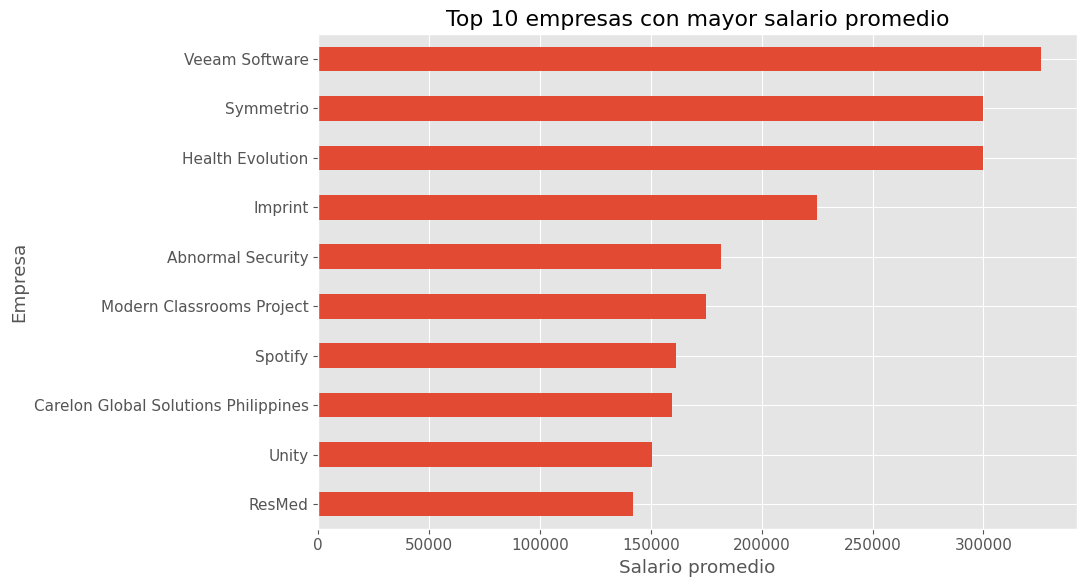

Imagen guardada: graficos/salarios_empresa.png


In [6]:
salarios = (
    df[df["salario_promedio"].notna()]
    .groupby("companyName")["salario_promedio"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 6))
salarios.sort_values().plot(kind="barh")

plt.title("Top 10 empresas con mayor salario promedio")
plt.xlabel("Salario promedio")
plt.ylabel("Empresa")

plt.tight_layout()

plt.savefig(
    os.path.join(CARPETA_GRAFICOS, "salarios_empresa.png"),
    dpi=300
)

plt.show()
plt.close()

print("Imagen guardada: graficos/salarios_empresa.png")

**Interpretación del gráfico:**

Veeam Software presenta el salario promedio más alto, con aproximadamente 330 000 dólares. Le siguen Symmetrio y Health Evolution, ambas con cerca de 300 000 dólares. En contraste, ResMed registra el menor salario del ranking, con alrededor de 140 000 dólares, generándose una diferencia de casi 190 000 dólares entre la primera y la última empresa.

* **Gráfico 2: Distribución de modalidades de empleo**

El gráfico representa la proporción de cada modalidad de contratación. Su interpretación permite conocer cuál es el tipo de empleo predominante en las ofertas publicadas.

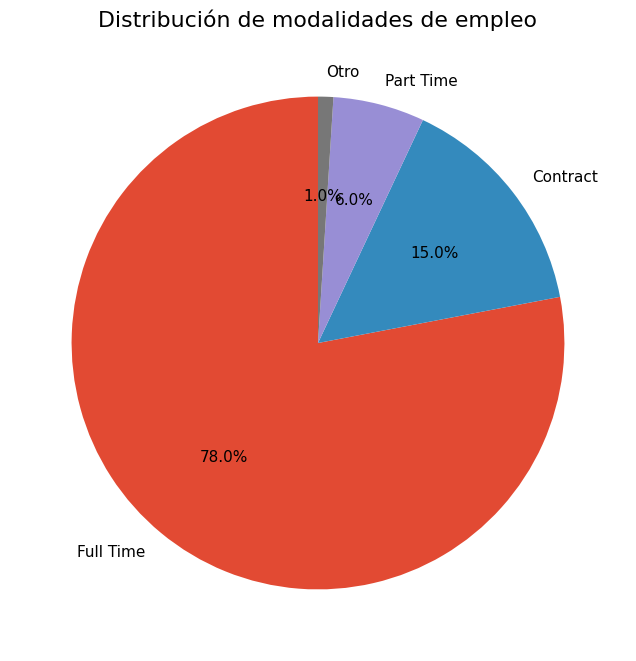

Imagen guardada: graficos/modalidades.png


In [7]:
modalidades = df["tipo_empleo_simple"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    modalidades,
    labels=modalidades.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribución de modalidades de empleo")

plt.savefig(
    os.path.join(CARPETA_GRAFICOS, "modalidades.png"),
    dpi=300
)

plt.show()
plt.close()

print("Imagen guardada: graficos/modalidades.png")

**Interpretación del gráfico:**

La modalidad Full Time concentra el 78 % de las ofertas, equivalente a 78 vacantes. Le sigue la modalidad Contract con 15 % (15 ofertas) y Part Time con 6 % (6 ofertas). La categoría Otro solo representa 1 oferta.

* **Gráfico 3: Tecnologías más demandadas**

Este gráfico muestra las tecnologías que aparecen con mayor frecuencia en las ofertas de trabajo. Permite identificar las habilidades técnicas más solicitadas por las empresas.

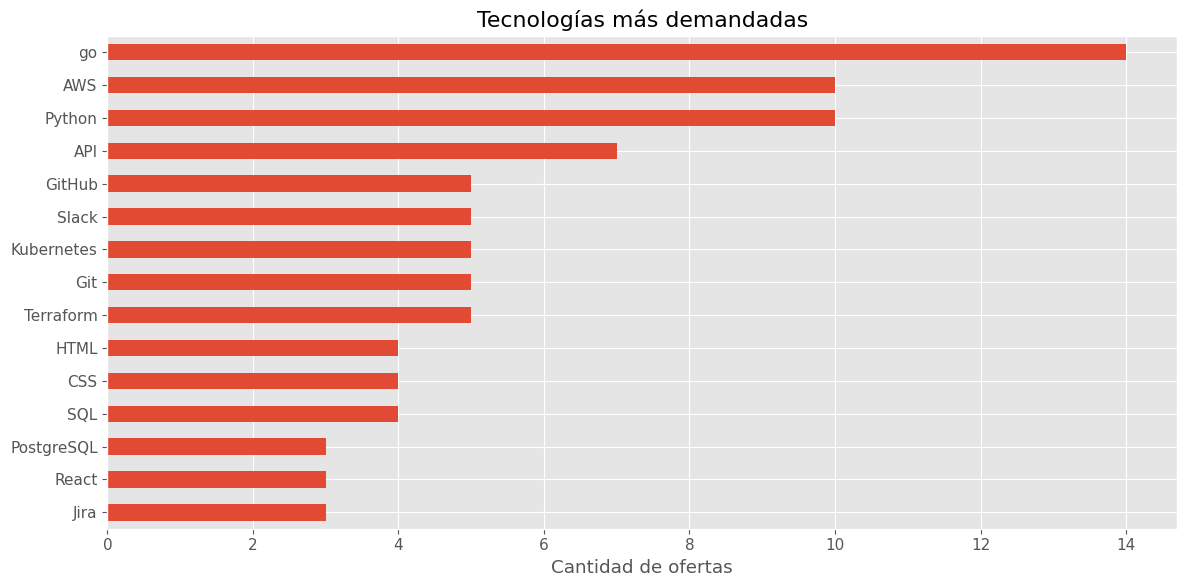

Imagen guardada: graficos/tecnologias.png


In [10]:
lista_tecnologias = []

for tecnologias in df["tecnologias"]:
    lista_tecnologias.extend(tecnologias)

conteo = (
    pd.Series(lista_tecnologias)
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 6))
conteo.sort_values().plot(kind="barh")

plt.title("Tecnologías más demandadas")
plt.xlabel("Cantidad de ofertas")

plt.tight_layout()

plt.savefig(
    os.path.join(CARPETA_GRAFICOS, "tecnologias.png"),
    dpi=300
)

plt.show()
plt.close()

print("Imagen guardada: graficos/tecnologias.png")

**Interpretación del gráfico:**

La tecnología más solicitada es Go, presente en 14 ofertas. Después aparecen AWS y Python, cada una con 10 ofertas. Por otro lado, React, PostgreSQL y Jira registran únicamente 3 ofertas, siendo las tecnologías menos demandadas dentro del top 15.

* **Gráfico 4: Nivel de experiencia requerido**

El gráfico presenta la cantidad de ofertas según el nivel de experiencia solicitado. Facilita identificar si las empresas buscan principalmente perfiles junior, intermedios o senior.

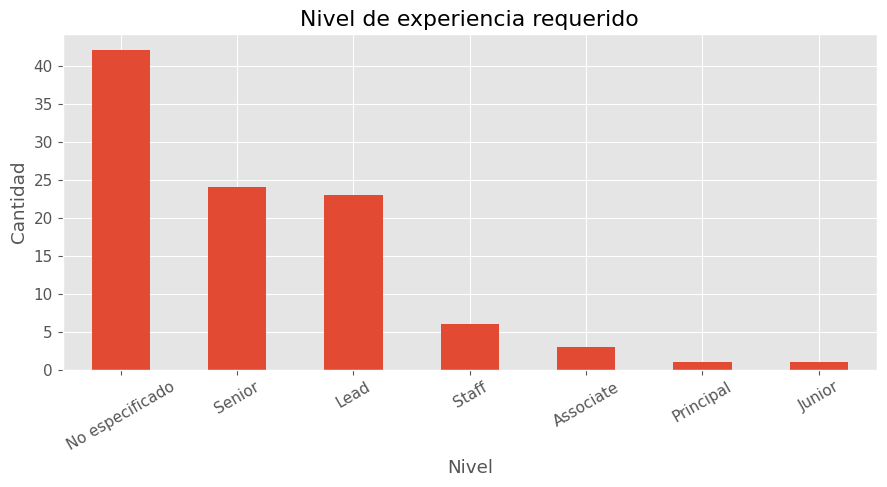

Imagen guardada: graficos/niveles_experiencia.png


In [8]:
niveles = df["nivel_experiencia"].value_counts()

plt.figure(figsize=(9, 5))
niveles.plot(kind="bar")

plt.title("Nivel de experiencia requerido")
plt.xlabel("Nivel")
plt.ylabel("Cantidad")

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    os.path.join(CARPETA_GRAFICOS, "niveles_experiencia.png"),
    dpi=300
)

plt.show()
plt.close()

print("Imagen guardada: graficos/niveles_experiencia.png")

**Interpretación del gráfico:**

La categoría No especificado es la más frecuente, con 42 ofertas. Entre las vacantes que sí indican experiencia, destacan los niveles Senior y Lead, con 24 y 23 ofertas, respectivamente. En cambio, los niveles Junior y Principal apenas aparecen en 1 oferta cada uno.

* **Gráfico 5: Heatmap Tecnologías vs Modalidad**

El mapa de calor muestra la relación entre las tecnologías requeridas y la modalidad de trabajo. Una mayor intensidad de color indica una mayor cantidad de ofertas que combinan una tecnología específica con una determinada modalidad laboral.

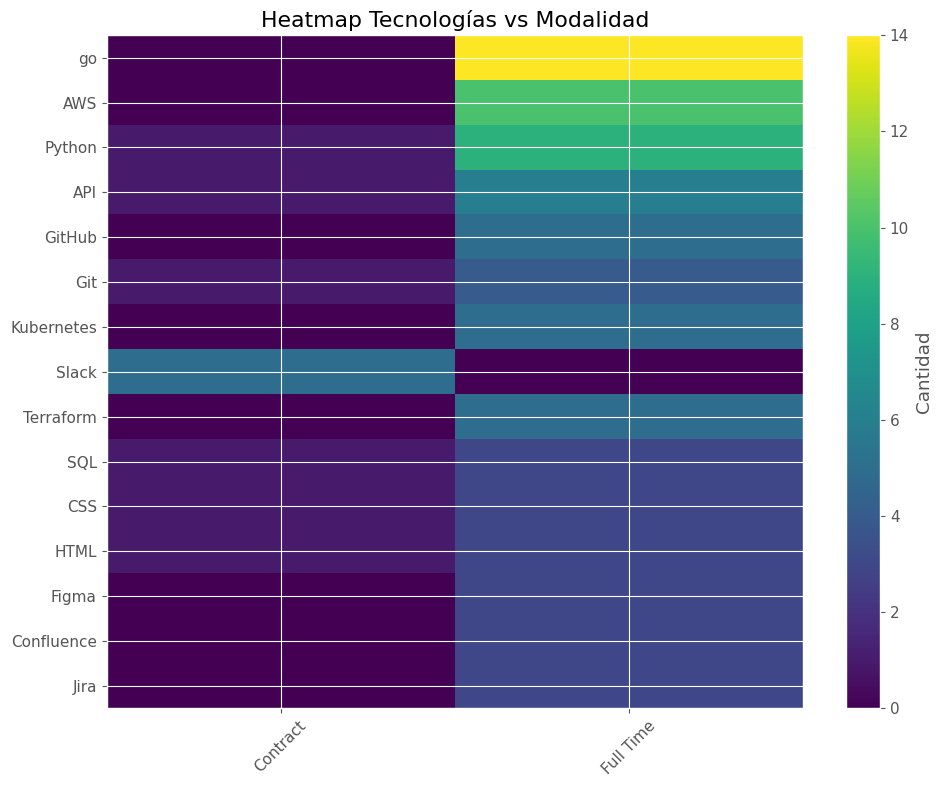

Imagen guardada: graficos/heatmap_tecnologias_modalidad.png


In [9]:
datos = []

for _, fila in df.iterrows():
    modalidad = fila["tipo_empleo_simple"]

    for tecnologia in fila["tecnologias"]:
        datos.append(
            {
                "Tecnologia": tecnologia,
                "Modalidad": modalidad
            }
        )

heat = pd.DataFrame(datos)

if len(heat) > 0:
    tabla = pd.crosstab(
        heat["Tecnologia"],
        heat["Modalidad"]
    )

    tabla = tabla.loc[
        tabla.sum(axis=1)
        .sort_values(ascending=False)
        .head(15)
        .index
    ]

    plt.figure(figsize=(10, 8))

    plt.imshow(
        tabla,
        aspect="auto"
    )

    plt.xticks(
        range(len(tabla.columns)),
        tabla.columns,
        rotation=45
    )

    plt.yticks(
        range(len(tabla.index)),
        tabla.index
    )

    plt.colorbar(label="Cantidad")
    plt.title("Heatmap Tecnologías vs Modalidad")

    plt.tight_layout()

    plt.savefig(
        os.path.join(CARPETA_GRAFICOS, "heatmap_tecnologias_modalidad.png"),
        dpi=300
    )

    plt.show()
    plt.close()

    print("Imagen guardada: graficos/heatmap_tecnologias_modalidad.png")

else:
    print("No hay datos suficientes para generar el heatmap")

**Interpretación del gráfico:**

Las tecnologías Go, AWS y Python presentan su mayor frecuencia en empleos Full Time, con aproximadamente 14, 10 y 9 ofertas, respectivamente. En la modalidad Contract, las cantidades son considerablemente menores, generalmente entre 0 y 2 ofertas por tecnología. Además, Slack destaca por tener una mayor presencia en contratos que otras tecnologías, con aproximadamente 5 ofertas Contract.

## **4. Conclusiones**
* El proyecto demostró que es posible obtener y analizar ofertas de empleo de forma automática utilizando una API, lo que facilita el acceso a información laboral de manera rápida y organizada.
* El procesamiento y la limpieza de los datos ayudaron a organizar la información obtenida, eliminando inconsistencias y dejando un conjunto de datos más adecuado para su análisis.
* La extracción de información desde las descripciones de las ofertas permitió obtener detalles que no estaban disponibles de forma directa, aportando una visión más completa de las características de los puestos publicados.
* El análisis realizado permitió obtener una visión más clara de las ofertas de empleo publicadas, facilitando la identificación de las características y tendencias más comunes presentes en las ofertas de trabajo recopiladas.